# Thyroid Cancer Recurrence Prediction

## Objective

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
# Loading dataset
df = pd.read_csv(r"C:\Users\THRISHA\OneDrive\Desktop\thyroid_cancer\Thyroid cancer dataset.csv")
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


## 3. Dataset Overview

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (383, 17)


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [5]:
# Statistical summary
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [6]:
# Checking missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [7]:
# Checking duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 19


## 4. Data Preprocessing

In [8]:
# Duplicate groups including their first occurrence
duplicate_records = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
duplicate_records.head(10)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
136,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
168,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
161,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
196,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
106,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
121,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
138,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
183,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
119,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
123,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No


In [9]:
# Removing duplicate records
df.drop_duplicates(inplace=True)
print("Duplicate Rows after removal:", df.duplicated().sum())
print("Updated Dataset Shape:", df.shape)

Duplicate Rows after removal: 0
Updated Dataset Shape: (364, 17)


In [10]:
# Initializing encoder
le = LabelEncoder()

# Categorical columns
categorical_columns = ['Gender','Smoking','Hx Smoking','Hx Radiothreapy','Thyroid Function','Physical Examination',
                       'Adenopathy','Pathology','Focality','Risk','T','N','M','Stage','Response','Recurred']
# Applying label encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0
1,34,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1,0
2,30,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
3,62,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
4,62,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,1,1,1,1,2,4,5,3,1,0,6,2,1,4,0,1
379,81,1,1,0,1,2,1,1,3,0,0,6,2,1,4,3,1
380,72,1,1,1,0,2,1,0,3,0,0,6,2,1,4,3,1
381,61,1,1,1,1,0,1,1,1,0,0,6,2,0,3,3,1


In [11]:
# Verifying updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   364 non-null    int64
 1   Gender                364 non-null    int32
 2   Smoking               364 non-null    int32
 3   Hx Smoking            364 non-null    int32
 4   Hx Radiothreapy       364 non-null    int32
 5   Thyroid Function      364 non-null    int32
 6   Physical Examination  364 non-null    int32
 7   Adenopathy            364 non-null    int32
 8   Pathology             364 non-null    int32
 9   Focality              364 non-null    int32
 10  Risk                  364 non-null    int32
 11  T                     364 non-null    int32
 12  N                     364 non-null    int32
 13  M                     364 non-null    int32
 14  Stage                 364 non-null    int32
 15  Response              364 non-null    int32
 16  Recurred     

## 5. Exploratory Data Analysis (EDA)

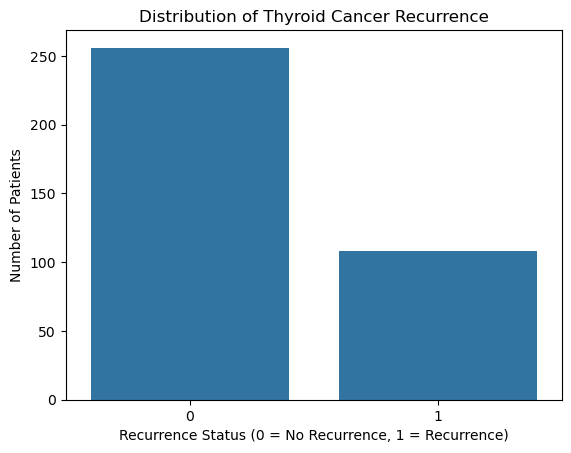

In [12]:
# Visualizing the distribution of recurrence cases
sns.countplot(x='Recurred', data=df)
plt.title('Distribution of Thyroid Cancer Recurrence')
plt.xlabel('Recurrence Status (0 = No Recurrence, 1 = Recurrence)')
plt.ylabel('Number of Patients')
plt.show()

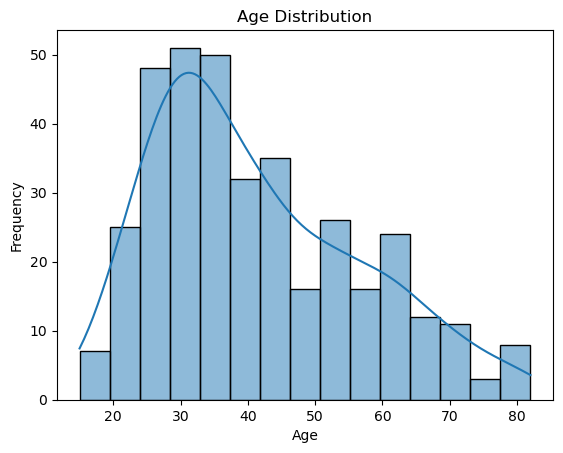

In [13]:
# Visualizing patient age distribution
sns.histplot(df['Age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

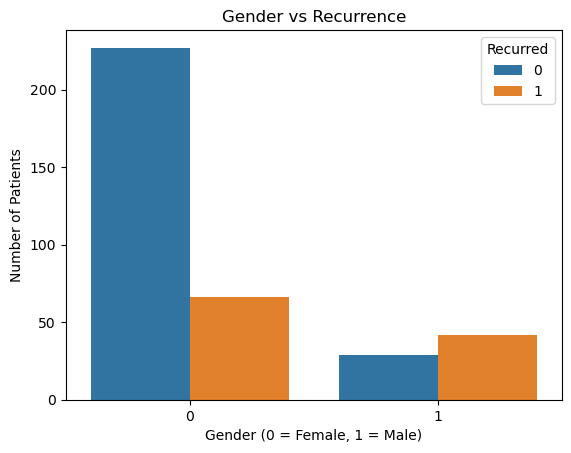

In [14]:
# Analyzing relationship between gender and recurrence
sns.countplot(x='Gender', hue='Recurred', data=df)
plt.title('Gender vs Recurrence')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Number of Patients')
plt.legend(title='Recurred')
plt.show()

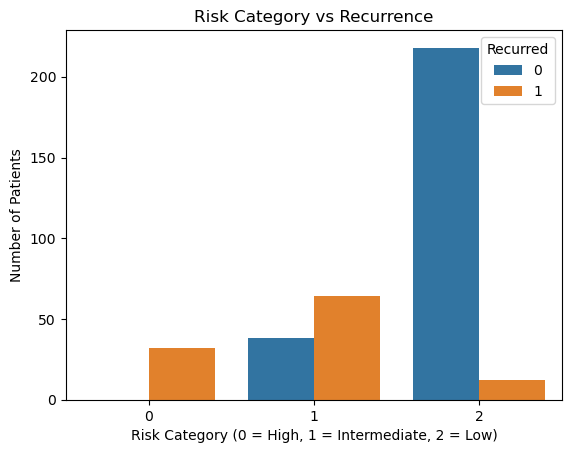

In [15]:
# Analyzing relationship between risk category and recurrence
sns.countplot(x='Risk', hue='Recurred', data=df)
plt.title('Risk Category vs Recurrence')
plt.xlabel('Risk Category (0 = High, 1 = Intermediate, 2 = Low)')
plt.ylabel('Number of Patients')
plt.legend(title='Recurred')
plt.show()

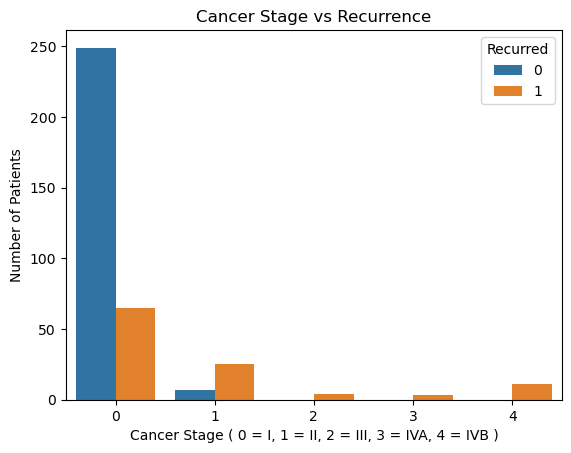

In [16]:
# Analyzing relationship between cancer stage and recurrence
sns.countplot(x='Stage', hue='Recurred', data=df)
plt.title('Cancer Stage vs Recurrence')
plt.xlabel('Cancer Stage ( 0 = I, 1 = II, 2 = III, 3 = IVA, 4 = IVB )')
plt.ylabel('Number of Patients')
plt.legend(title='Recurred')
plt.show()

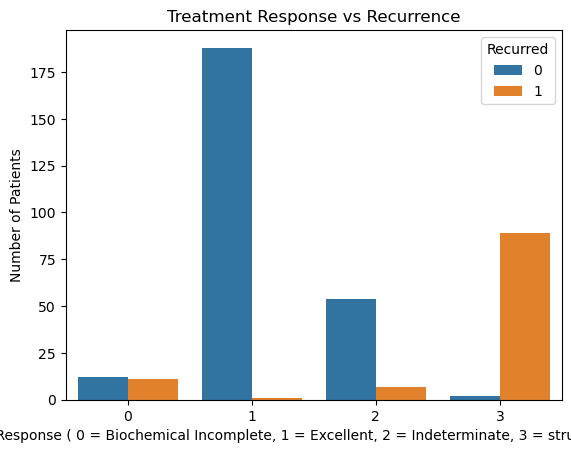

In [17]:
# Analyzing relationship between treatment response and recurrence
sns.countplot(x='Response', hue='Recurred', data=df)
plt.title('Treatment Response vs Recurrence')
plt.xlabel('Treatment Response ( 0 = Biochemical Incomplete, 1 = Excellent, 2 = Indeterminate, 3 = structural Incomplete )')
plt.ylabel('Number of Patients')
plt.legend(title='Recurred')
plt.show()

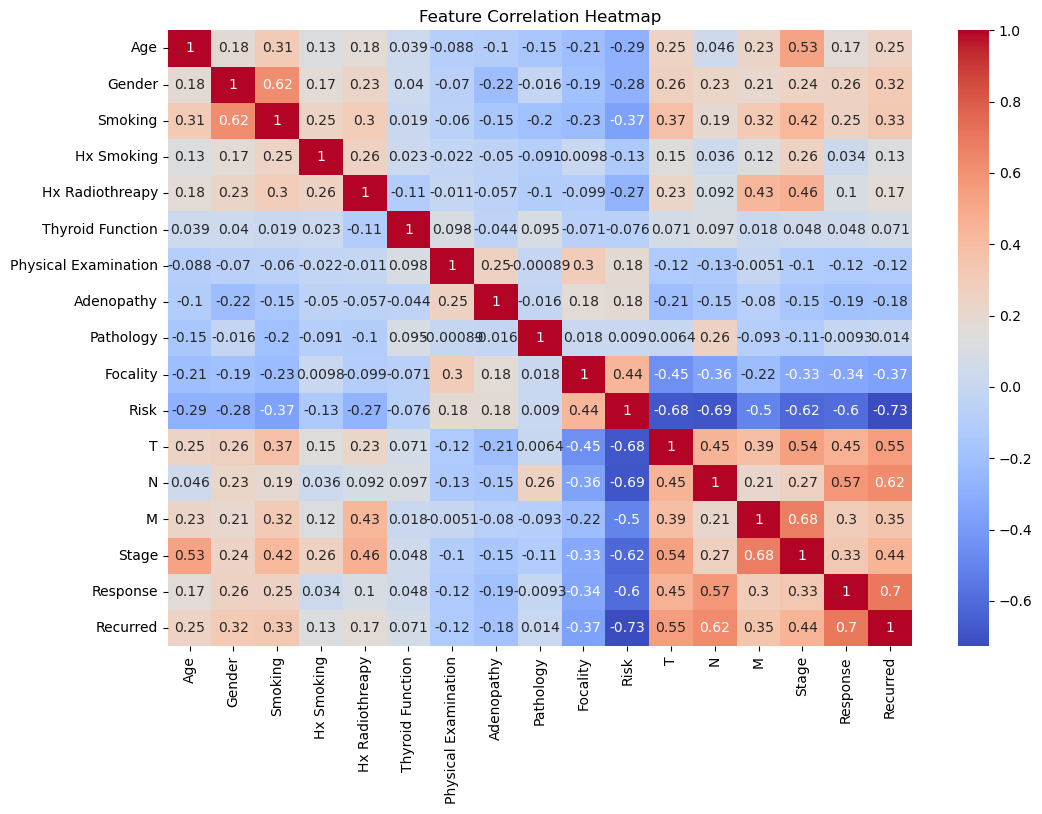

In [18]:
# Creating correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 6. Feature and Target Separation

In [19]:
# Separate input features and target variable
X = df.drop('Recurred', axis=1)
y = df['Recurred']
print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (364, 16)
Target Shape : (364,)


## 7. Train-Test Split

In [20]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (291, 16)
X_test Shape : (73, 16)
y_train Shape: (291,)
y_test Shape : (73,)


## 8. Feature Scaling

In [21]:
# Initializing StandardScaler
scaler = StandardScaler()

# Scale training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled Shape :", X_train_scaled.shape)
print("X_test_scaled Shape  :", X_test_scaled.shape)

X_train_scaled Shape : (291, 16)
X_test_scaled Shape  : (73, 16)


## 9. Model Training and Evaluation

### 9.1 Logistic Regression

In [22]:
# Initializing Logistic Regression model
lr = LogisticRegression(random_state=42)

# Training the model
lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [23]:
# Predictions on test data
y_pred_lr = lr.predict(X_test_scaled)

In [24]:
# Evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.8493150684931506
Precision: 0.7894736842105263
Recall   : 0.6818181818181818
F1 Score : 0.7317073170731707


In [25]:
# Classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.92      0.90        51
           1       0.79      0.68      0.73        22

    accuracy                           0.85        73
   macro avg       0.83      0.80      0.81        73
weighted avg       0.85      0.85      0.85        73



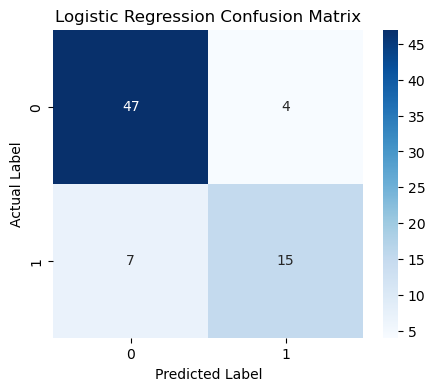

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.2 Support Vector Classifier (SVC)

In [27]:
# Initializing SVC model
svc_model = SVC(random_state=42)

# Training the model
svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [28]:
# Predictions using SVC model
y_pred_svc = svc_model.predict(X_test_scaled)

In [29]:
# Evaluation metrics
svc_accuracy = accuracy_score(y_test, y_pred_svc)
svc_precision = precision_score(y_test, y_pred_svc)
svc_recall = recall_score(y_test, y_pred_svc)
svc_f1 = f1_score(y_test, y_pred_svc)

print("Accuracy :", svc_accuracy)
print("Precision:", svc_precision)
print("Recall   :", svc_recall)
print("F1 Score :", svc_f1)

Accuracy : 0.9041095890410958
Precision: 0.8571428571428571
Recall   : 0.8181818181818182
F1 Score : 0.8372093023255814


In [30]:
# Classification report
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        51
           1       0.86      0.82      0.84        22

    accuracy                           0.90        73
   macro avg       0.89      0.88      0.88        73
weighted avg       0.90      0.90      0.90        73



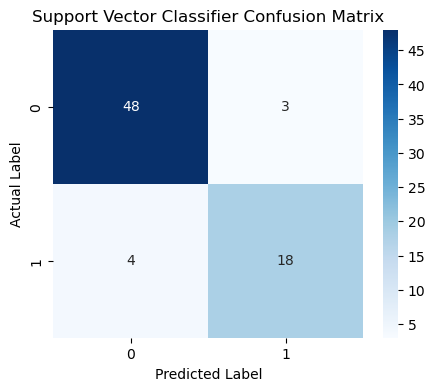

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Support Vector Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.3 Decision Tree Classifier

In [32]:
# Initializing Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Training the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [33]:
# Predictions using Decision Tree model
y_pred_dt = dt_model.predict(X_test)

In [34]:
# Evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.9178082191780822
Precision: 0.8076923076923077
Recall   : 0.9545454545454546
F1 Score : 0.875


In [35]:
# Classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94        51
           1       0.81      0.95      0.88        22

    accuracy                           0.92        73
   macro avg       0.89      0.93      0.91        73
weighted avg       0.93      0.92      0.92        73



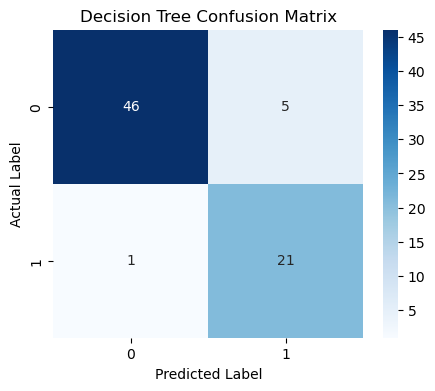

In [36]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.4 Random Forest Classifier

In [37]:
# Initializing Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

# Training the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [38]:
# Predictions using Random Forest model
y_pred_rf = rf_model.predict(X_test)

In [39]:
# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.958904109589041
Precision: 0.9130434782608695
Recall   : 0.9545454545454546
F1 Score : 0.9333333333333333


In [40]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        51
           1       0.91      0.95      0.93        22

    accuracy                           0.96        73
   macro avg       0.95      0.96      0.95        73
weighted avg       0.96      0.96      0.96        73



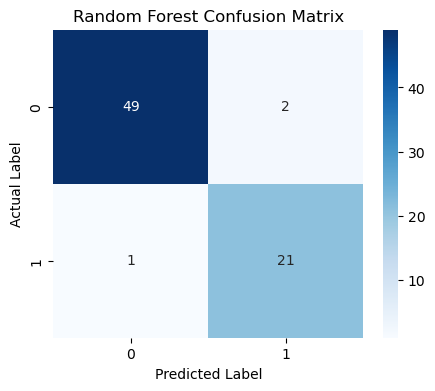

In [41]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 10. Model Comparison

In [42]:
# Model comparison table
comparison_df = pd.DataFrame({'Model': ['Logistic Regression','Support Vector Classifier (SVC)','Decision Tree Classifier','Random Forest Classifier'],
                              'Accuracy': [lr_accuracy,svc_accuracy,dt_accuracy,rf_accuracy],
                              'Precision': [lr_precision,svc_precision,dt_precision,rf_precision],
                              'Recall': [lr_recall,svc_recall,dt_recall,rf_recall],
                              'F1 Score': [lr_f1,svc_f1,dt_f1,rf_f1]})
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.849315,0.789474,0.681818,0.731707
1,Support Vector Classifier (SVC),0.904110,0.857143,0.818182,0.837209
2,Decision Tree Classifier,0.917808,0.807692,0.954545,0.875000
3,Random Forest Classifier,0.958904,0.913043,0.954545,0.933333


## 11. Final Model Selection

Logistic Regression, Support Vector Classifier (SVC), Decision Tree, and Random Forest Classifier models were trained and evaluated for thyroid cancer recurrence prediction. Although Logistic Regression and SVC achieved strong performance, Decision Tree and Random Forest Classifiers demonstrated superior ability in identifying recurrence cases.

Among all the models, the Random Forest classifier achieved the highest accuracy, precision, and F1-score while maintaining an excellent recall value. The model correctly identified 21 out of 22 recurrence cases while producing only 2 false positive predictions.

Since accurately identifying recurrence cases is critical in medical applications, **the Random Forest Classifier was selected as the final model for thyroid cancer recurrence prediction.**

## 12. Prediction

In [43]:
# Sample patient data for Prediction
sample_patient = pd.DataFrame({'Age': [27],'Gender': [0],'Smoking': [0],'Hx Smoking': [0],'Hx Radiothreapy': [0],'Thyroid Function': [2],
                               'Physical Examination': [3],'Adenopathy': [3],'Pathology': [2],'Focality': [1],'Risk': [2],'T': [0],'N': [0],
                               'M': [0],'Stage': [0],'Response': [2]})

prediction = rf_model.predict(sample_patient)
if prediction[0] == 1:
    print("Prediction: The patient is likely to experience thyroid cancer recurrence.")
else:
    print("Prediction: The patient is unlikely to experience thyroid cancer recurrence.")

Prediction: The patient is unlikely to experience thyroid cancer recurrence.


In [44]:
# Sample patient data for Prediction
sample_patient = pd.DataFrame({'Age': [61],'Gender': [1],'Smoking': [1],'Hx Smoking': [1],'Hx Radiothreapy': [1],'Thyroid Function': [0],
                               'Physical Examination': [1],'Adenopathy': [1],'Pathology': [1],'Focality': [0],'Risk': [0],'T': [6],'N': [2],
                               'M': [0],'Stage': [3],'Response': [3]})

prediction = rf_model.predict(sample_patient)
if prediction[0] == 1:
    print("Prediction: The patient is likely to experience thyroid cancer recurrence.")
else:
    print("Prediction: The patient is unlikely to experience thyroid cancer recurrence.")

Prediction: The patient is likely to experience thyroid cancer recurrence.
